In [1]:
import ultraplot as uplt
import astropy.units as u
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.visualization.wcsaxes import SphericalCircle

In [2]:
coords = SkyCoord("04h30m49.1s +64d50m53.0s")
coords

<SkyCoord (ICRS): (ra, dec) in deg
    (67.70458333, 64.84805556)>

In [3]:
npix = 100
radius = (246.68296780422142 * u.arcsecond).to(u.deg)
dra = ddec = (2.2 * radius / npix).value
dra = -dra
wcs = WCS(
    {
        "CTYPE1": "RA---SIN",
        "CTYPE2": "DEC--SIN",
        "CUNIT1": "deg",
        "CUNIT2": "deg",
        "CDELT1": dra,
        "CDELT2": ddec,
        "NAXIS1": npix,
        "NAXIS2": npix,
        "CRPIX1": npix / 2,
        "CRPIX2": npix / 2,
        "CRVAL1": coords.ra.deg,
        "CRVAL2": coords.dec.deg,
        "PC1_1 ": 1.0,
        "PC1_2 ": 0.0,
        "PC2_1 ": 0.0,
        "PC2_2 ": 1.0,
    }
)

TypeError: Artist.get_transform() takes 1 positional argument but 2 were given

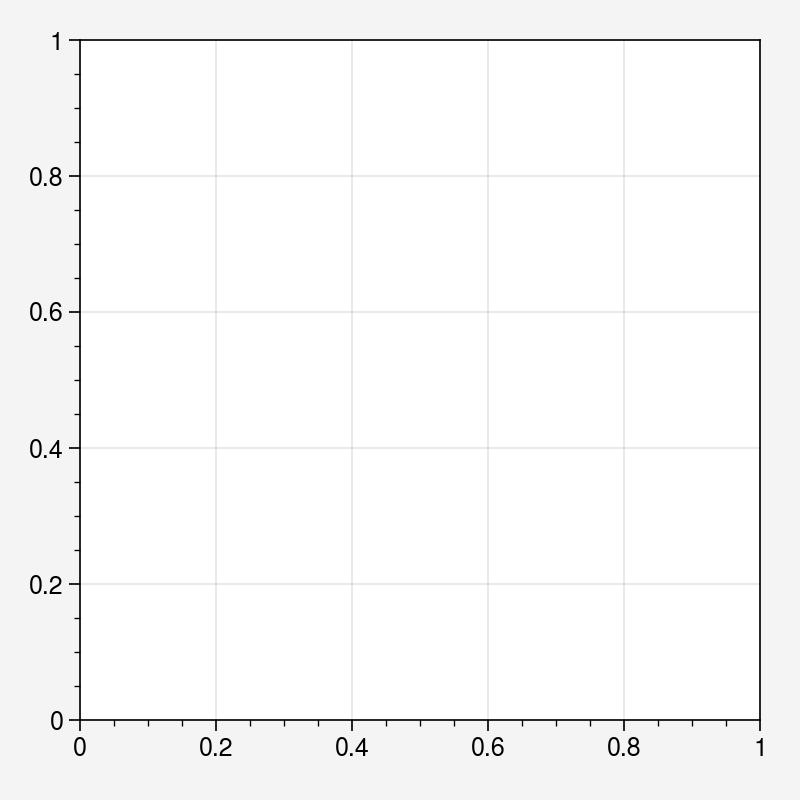

In [4]:
fig = uplt.figure()
ax = fig.add_axes([0.1,0.1,0.85,0.85], projection=wcs)
ax.plot(
    coords.ra,
    coords.dec,
    ".",
    transform=ax.get_transform("icrs"),
    mec="b",
    mfc="none",
)
circle = SphericalCircle(
    coords,
    radius,
    edgecolor="r",
    facecolor="none",
    transform=ax.get_transform("icrs"),
)
ax.add_patch(circle)
uplt.show()

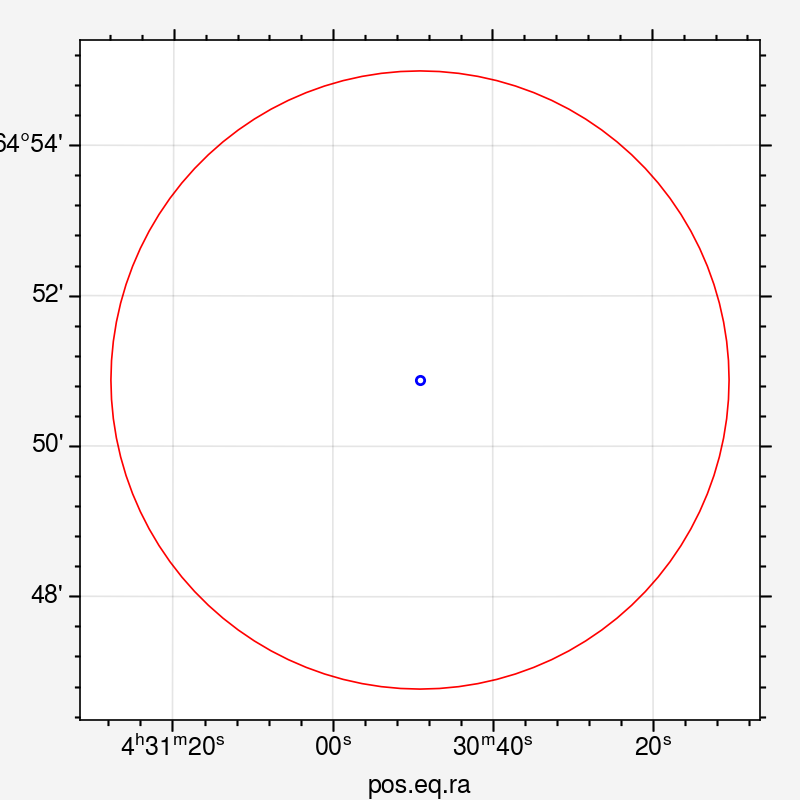

In [5]:
fig = plt.figure(1)
ax = fig.add_axes([0.1,0.1,0.85,0.85], projection=wcs)
ax.plot(
    coords.ra,
    coords.dec,
    ".",
    transform=ax.get_transform("icrs"),
    mec="b",
    mfc="none",
)
circle=SphericalCircle(
    coords,
    radius,
    edgecolor="r",
    facecolor="none",
    transform=ax.get_transform("icrs"),
)
ax.add_patch(circle)
plt.show()